<a href="https://colab.research.google.com/github/srishti-parulekar/studyML/blob/main/ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Preprocessing

Ai is the ability of a computer to mimic human intelligence.
Machine learning enables computers to learn from data and make predictions.

ML process:
Data preprocesing (import data, clean the data and split into training and testing sets).
Modeling: build and train the model, make predictions.
Evaluation: calculate performance metrics.

Types of learning:
Supervised Learning:

What is feature scaling?
Feature scaling is always applied to columns, never to data inside the rows.
Two main types:
Normalisation and Standardization:

With normalising a column: each entry X is modified to become X - Xmin / Max - Min;
Each new column entry is now between the values 0 and 1.

Standardization: X - u / p where u is the average and p is the standard deviation. All the values mostly between [-3,3]

Feature scaling is necessary when grouping data values or clustering algorithms to check compatibility between values and the scale of the columns is drastically different so that the values can be normalised and one column wont overpower the other.

Dependent variables are the varaibles that you want your model to predict while independent variables or features are the variables that are given to the model and the model uses them to make the prediction.

We use the iloc function from pandas: stands for locate indexes. This allows us to split the columns or rows of the dataframe to create a new data frame.

Missing values can be replaced using SImpleImputer.

IMP: upper bound of range in python
The fit() method helps in fitting the data into a model, transform() method helps in transforming the data into a form that is more suitable for the model.

How do we encode categorical data?
If we encode the company names of India, France and Germany as 0,1,2 it may work for our operations but the model may assume that the ordering has some significance which is not the case, so this cannot be done as it could cause misinterpreted correlations.

We can do so by using binary vectors for the (independent variables)countries ( 1,0,0 and 0,1,0 and 0,0,1) and for binary values (0,1) for the (dependent) outcomes being yes and no.
This is done using One Hot Encoding.
Label encoding is being used for the binary value encoding of no and yes.
OneHotEncoder after transforming doesnt return a np array so that needs to be taken care of separately.

Do we perform feature scaling before or after splitting the data into training and testing sets? AFTER.
The test set is supposed to be a brand new set. The feature scaling takes the mean and the standard deviation of all values including the test set, there would be information leakage on the test set.

When to use standardisation and when to use normalisation?
Normalisation is great when you have a normal distribution in most of your features.
Standardisation is great always.

Do we have to apply feature scaling to the dummy variables in the matrix of features? NO.
Post standardisation all the values of the variables will be between -3 and 3. Since dummy variables have binary values of 0 and 1 already, they are already in range. Standardisation will make it worse since it will transform these values to be between -3 and 3 but we will lose the interpretation of these values that we need to train our model.

Delimiters used when the csv file has its row values separated by something other than commas,
Example if separated by ;
dataset = pd.read_csv('winequality-red.csv', sep=';')

Regression models (both linear and non-linear) are used for predicting a real value, like salary for example. If your independent variable is time, then you are forecasting future values, otherwise your model is predicting present but unknown values.

In [ ]:
import numpy as np
# numpy allows us to work with arrays
import matplotlib.pyplot as plt
# allows us to plot graphs, importing the pyplot module in specific
import pandas as pd
# good to preprocess datasets

In [ ]:
dataset = pd.read_csv('Data.csv')
X = dataset.iloc[:, :-1].values
# taking all the rows, and all the columns except the last column which is the dependent variable.
y = dataset.iloc[:, -1].values
# takes all the rows and only the last column
# X and y are numpy arrays necessarily so that the train() function can be applied on them.

In [ ]:
print(X)

[['France' 44.0 72000.0]
 ['Spain' 27.0 48000.0]
 ['Germany' 30.0 54000.0]
 ['Spain' 38.0 61000.0]
 ['Germany' 40.0 nan]
 ['France' 35.0 58000.0]
 ['Spain' nan 52000.0]
 ['France' 48.0 79000.0]
 ['Germany' 50.0 83000.0]
 ['France' 37.0 67000.0]]


In [ ]:
print(y)

['No' 'Yes' 'No' 'No' 'Yes' 'Yes' 'No' 'Yes' 'No' 'Yes']


Taking care of missing data!

In [ ]:
# for large datasets, you can just delete the rows that have missing data.
# not always efficient, can instead replace the missing data value.
# missing value can be replaced by average or by the median value of that column or something else too.

from sklearn.impute import SimpleImputer
#
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
# creating imputer object with parameters stating which data values to replace with what strategy.
imputer.fit(X[:, 1:3])
# since in python upperbound is not included for column number 1 and 2: [1,3] is used.
X[:, 1:3] = imputer.transform(X[:, 1:3])

In [ ]:
print(X)

[['France' 44.0 72000.0]
 ['Spain' 27.0 48000.0]
 ['Germany' 30.0 54000.0]
 ['Spain' 38.0 61000.0]
 ['Germany' 40.0 63777.77777777778]
 ['France' 35.0 58000.0]
 ['Spain' 38.77777777777778 52000.0]
 ['France' 48.0 79000.0]
 ['Germany' 50.0 83000.0]
 ['France' 37.0 67000.0]]


One Hot Encoding


In [ ]:
# encoding the independent variable:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [ ]:
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [0])], remainder='passthrough')
# transformer parameter contains the transformation that needs to be done: encoding, the class that will perform the encoding
# ie OneHotEncoder, the third element is the indexes of the column on which we want to perform the encoding,
# here it is the country column only.

# remainder is going to state that we want to keep the columns that we are not applying the transformation too as well.

X = np.array(ct.fit_transform(X))
# here ct.fit_transform() doesnt automatically return a numpy array

In [ ]:
print(X)

[[1.0 0.0 0.0 44.0 72000.0]
 [0.0 0.0 1.0 27.0 48000.0]
 [0.0 1.0 0.0 30.0 54000.0]
 [0.0 0.0 1.0 38.0 61000.0]
 [0.0 1.0 0.0 40.0 63777.77777777778]
 [1.0 0.0 0.0 35.0 58000.0]
 [0.0 0.0 1.0 38.77777777777778 52000.0]
 [1.0 0.0 0.0 48.0 79000.0]
 [0.0 1.0 0.0 50.0 83000.0]
 [1.0 0.0 0.0 37.0 67000.0]]


france is encoded as 1.0, 0.0, 0.0
germany as 0.0 0.0 1.0 and so on

Encode the dependent var

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
le = LabelEncoder()
y = le.fit_transform(y)

In [ ]:
print(y)

[0 1 0 0 1 1 0 1 0 1]


Splitting the dataset into training and testing.

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=1)

# ensures that the same randomization is used each time you run the code, resulting in the same splits of the data.

In [ ]:
print(X_train)

[[0.0 0.0 1.0 38.77777777777778 52000.0]
 [0.0 1.0 0.0 40.0 63777.77777777778]
 [1.0 0.0 0.0 44.0 72000.0]
 [0.0 0.0 1.0 38.0 61000.0]
 [0.0 0.0 1.0 27.0 48000.0]
 [1.0 0.0 0.0 48.0 79000.0]
 [0.0 1.0 0.0 50.0 83000.0]
 [1.0 0.0 0.0 35.0 58000.0]]


In [ ]:
print(X_test)

[[0.0 1.0 0.0 30.0 54000.0]
 [1.0 0.0 0.0 37.0 67000.0]]


In [ ]:
print(y_train)

[0 1 0 0 1 1 0 1]


In [ ]:
print(y_test)

[0 1]


Feature Scaling (always after Splitting!)

In [ ]:
# not always applied
# normalisation good when normal distribution for most of your features, standardisation is always good.

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()


In [ ]:
X_train[:,3:] = sc.fit_transform(X_train[:,3:])
# fit will just give the mean and the std dev of the columns, transform will actually change each entry in the column.
# by applying the formula.

In [ ]:
# we need to standardise the test values by the same scaler (ie using the calculated mean and std dev of the training set)
# and not its own scaler since that would cause information leakage,
# we already fitted sc with the scaler for the training set so we use the same values of mean and std dev
# and directly apply transform of the test set.
X_test[:,3:] = sc.transform(X_test[:,3:])

In [ ]:
print(X_train)

[[0.0 0.0 1.0 -0.19159184384578545 -1.0781259408412425]
 [0.0 1.0 0.0 -0.014117293757057777 -0.07013167641635372]
 [1.0 0.0 0.0 0.566708506533324 0.633562432710455]
 [0.0 0.0 1.0 -0.30453019390224867 -0.30786617274297867]
 [0.0 0.0 1.0 -1.9018011447007988 -1.420463615551582]
 [1.0 0.0 0.0 1.1475343068237058 1.232653363453549]
 [0.0 1.0 0.0 1.4379472069688968 1.5749910381638885]
 [1.0 0.0 0.0 -0.7401495441200351 -0.5646194287757332]]


In [ ]:
print(X_test)

[[0.0 1.0 0.0 -1.4661817944830124 -0.9069571034860727]
 [1.0 0.0 0.0 -0.44973664397484414 0.2056403393225306]]


# Simple Regression

Regression is when you have to predict continuous real values and classification is when you have to predict a category.

Regression models (both linear and non-linear) are used for predicting a real value, like salary for example.
If your independent variable is time, then you are forecasting future values, otherwise your model is predicting present but unknown values.

Simple Linear Regression equation:
dependent variable = y-intercept + slope*Independent variable

How do we decide which slope line is the best one?

Ordinary Least Squares:
Residual for each point on the scatter plot is calculated, residual is the difference between the predicted value of that data point by the regression model and its actual value.


The line is chosen, that is the slope and the intercept are set such that the sum of the squares of all residuals is minimum.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
dataset = pd.read_csv('Salary_Data.csv')
X = dataset.iloc[:,:-1].values
y = dataset.iloc[:,-1].values

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=0)

In [ ]:
from sklearn.linear_model import LinearRegression

# training the regression model on the training set
regressor = LinearRegression()
regressor.fit(X_train,y_train)


LinearRegression()

In [ ]:
# predicting the test set results:
y_pred = regressor.predict(X_test)
# returns a vector of predictions

visualising the training set results

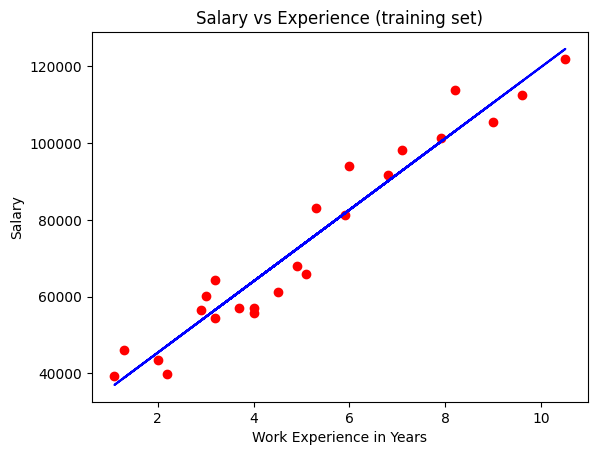

In [ ]:
plt.scatter(X_train,y_train, color='red')
plt.plot(X_train,regressor.predict(X_train), color='blue')
plt.title('Salary vs Experience (training set)')
plt.xlabel('Work Experience in Years')
plt.ylabel('Salary')
plt.show()

visualising the test set results

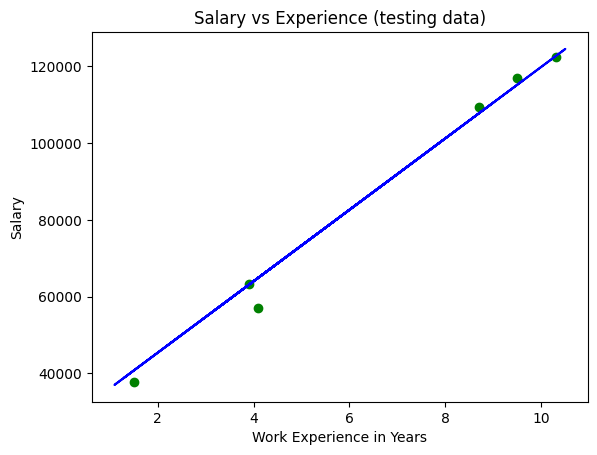

In [ ]:
plt.scatter(X_test, y_test, color='green')
# the predicted salaries of the testing set will be on the same line as the predicted salaries of the training set.
# therefore no changes to plot
plt.plot(X_train, regressor.predict(X_train), color='blue' )
plt.title('Salary vs Experience (testing data)')
plt.xlabel('Work Experience in Years')
plt.ylabel('Salary')
plt.show()

Simple linear regression is when you are plotting against only one feature, multiple linear regression is when you are plotting against multiple features.

analysing startup success prediction:
equation for multiple linear regression:
dependent variable = y-intercept + slope*independent + slope2*independent2 and so on.

Anscombe's quartet shows that linear regression should not be applied blindly and should only be applied when the requirement exists.

Assumptions of linear regression:
- There needs to be a linear relationship between the dependent and the independent variables.
- homoscedasticity: equal variance.
- multivariant normality: normality of error distribution
- independence of objects: no auto correlation.
- independent variables or features should not be related to each other, should not be correlated.
- outlier check




# Multiple Linear Regression

Multiple linear regression (MLR) is a statistical technique that predicts the value of a dependent variable using multiple independent variables.

profit is dependent and all others are independent
whenever you see categorical variables you need to turn them into dummy variables.
multiple linear regression:

profit = b0 + b1*marketing + b2*admin + b3*r&d + ??? since state is a categorical value.

the categorical value column here is state and it has two values: NY and CA. therefore we need to split it into two further columns. NY column will have values 1 for all NY columns else 0 and the same with CA.

profit = b0 + b1marketing + b2admin + b3*r&d + b4*D1 where D1 is the dummy value column for NY. we include only one of the columns of the dummy data here for a reason.

b0 accounts for california, if b4 is non zero then the equation becomes one for NY, but if b4 is zero then the value in b0 accounts for CA.

so b0 that is the default state accounts for cali.

why cant we include the dummy variable columns for both?
since D2 = 1-D1 always, since in multiple regression multiple independent variables are used to predict a dependent variable, the model cannot distinguish between the effects of D1 and D2, which wont allow the model to work properly, this is called the dummy variable trap.

the real problem is that we cannot have these three elements in the equation at the same time: b0, D1 and D2.


**irrespective of the number of dummy variables, always omit ONE dummy variable column. this column will be accounted for by the b0 column. **

#What is statistical significance?


The null hypothesis and alternative hypothesis are competing statements that are used in statistical hypothesis testing. The null hypothesis is the default assumption, while the alternative hypothesis challenges it.

If we are tossing a coin:
In our scenario we can state that, null hypothesis is the scenario where the coin is a fair coin.

in H1: the coin is not fair.


for H0:
if the coin is tossed six times and each time we get tails, the probability of the whole event drops with each occurrence ie the probability or the p-value of getting 6 tails in a row drops from 0.5 to 0.01 on the sixth tail.

for H1 universe: where the coin can be weighted or both sides of the coin can be tails:
the p-values would be 100% for each occurrence.


but in hypothesis testing: we assume we are in a null hypothesis universe and we calculate by how much the likelihood of a collective event decreases with each occurrence.

#statistic significance
is the value: p-value of 0.5 ie 5% where you can start questioning the null hypothesis.

after the statistic significance you can reject H0, and accept H1. you can set the statistical hypothesis based on the experiment.

the point in human intuitive terms, you get uneasy about the null hypothesis.

out of all the independent variables, we need to understand which to include and which to not:


5 ways of building a model:
1. all in
2. backward elimination
3. forward selection
4. bidirectional elimination
5. score comparison

stepwise regression refers to backward elimination, forward selection and bidirectional elimination.

All in:
all the independent columns are included in the model.


when is it used?
1. prior knowledge: knowing all columns are required.
2. you have to
3. preparing for backward elimination

backward elimination

1. fix the significance level.
2. fit the full model with all possible predictors.
3. consider the predictors with the highest p-values. if P>SL then go to
step 4, else go to FIN.
4. remove this predictor from the model.
5. fit the model without this variable everytime because when you remove one variable it affects all the variables of the model, the coefficients and all change.

repeat steps 3,4,5 till: even the highest p-value in your system is less than your significance level.



forward selection

1. select the significance level (5% for now)
2. fit all simple regression models and select the one with the lowest p-value.
3. keep this variable as common and fit all possible models with one extra predictor added to the one you already have.
4. for example in the first iteration you will now be creating regression models with two variables and in second iteration with three variables and so on. out of all these models consider the predictor with the LOWEST P-VALUE again and proceed with it to step 3 if P < SL is still true. or go to FIN.

the variable you add that makes the P>SL is tossed, so the second last model is the one that is chosen.


bidirectional elimination

1. select the significance level
2. perform the first step of forward selection ie. include a variable as long as P<SL.
3. perform ALL the steps of backward elimination. (old variables must stay if the P>SL else removed)
4. keep execution 2->3->2->3...till no new variables can enter and no old variables can exit.

FIN: model is ready

All possible methods:
1. select a criterion to evaluate the model eg. Akaike criterion.
2. compute all possible regression models, for n variables there will be 2^n -1 possible models. compute them all.
3. select the one with the best criterion.

FIN: this is your final model.

In [1]:
import pandas as pd
import numpy as np

dataset = pd.read_csv('50_Startups.csv')
dataset.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [2]:
X = dataset.iloc[:,:-1].values
y = dataset.iloc[:,-1].values

In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(),[3])], remainder='passthrough')

X = np.array(ct.fit_transform(X))

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test,y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=0)

In [5]:
print(X_train)

[[0.0 1.0 0.0 55493.95 103057.49 214634.81]
 [0.0 0.0 1.0 46014.02 85047.44 205517.64]
 [0.0 1.0 0.0 75328.87 144135.98 134050.07]
 [1.0 0.0 0.0 46426.07 157693.92 210797.67]
 [0.0 1.0 0.0 91749.16 114175.79 294919.57]
 [0.0 1.0 0.0 130298.13 145530.06 323876.68]
 [0.0 1.0 0.0 119943.24 156547.42 256512.92]
 [0.0 0.0 1.0 1000.23 124153.04 1903.93]
 [0.0 0.0 1.0 542.05 51743.15 0.0]
 [0.0 0.0 1.0 65605.48 153032.06 107138.38]
 [0.0 0.0 1.0 114523.61 122616.84 261776.23]
 [0.0 1.0 0.0 61994.48 115641.28 91131.24]
 [1.0 0.0 0.0 63408.86 129219.61 46085.25]
 [1.0 0.0 0.0 78013.11 121597.55 264346.06]
 [1.0 0.0 0.0 23640.93 96189.63 148001.11]
 [1.0 0.0 0.0 76253.86 113867.3 298664.47]
 [0.0 0.0 1.0 15505.73 127382.3 35534.17]
 [0.0 0.0 1.0 120542.52 148718.95 311613.29]
 [1.0 0.0 0.0 91992.39 135495.07 252664.93]
 [1.0 0.0 0.0 64664.71 139553.16 137962.62]
 [0.0 0.0 1.0 131876.9 99814.71 362861.36]
 [0.0 0.0 1.0 94657.16 145077.58 282574.31]
 [1.0 0.0 0.0 28754.33 118546.05 172795.67]
 [1.

In [6]:
print(X_test)

[ 96778.92  96479.51 105733.54  96712.8  124266.9  155752.6  132602.65
  64926.08  35673.41 101004.64 129917.04  99937.59  97427.84 126992.93
  71498.49 118474.03  69758.98 152211.77 134307.35 107404.34 156991.12
 125370.37  78239.91  14681.4  191792.06 141585.52  89949.14 108552.04
 156122.51 108733.99  90708.19 111313.02 122776.86 149759.96  81005.76
  49490.75 182901.99 192261.83  42559.73  65200.33]


In [7]:
print(y_train)

[[0.0 1.0 0.0 66051.52 182645.56 118148.2]
 [1.0 0.0 0.0 100671.96 91790.61 249744.55]
 [0.0 1.0 0.0 101913.08 110594.11 229160.95]
 [0.0 1.0 0.0 27892.92 84710.77 164470.71]
 [0.0 1.0 0.0 153441.51 101145.55 407934.54]
 [0.0 0.0 1.0 72107.6 127864.55 353183.81]
 [0.0 0.0 1.0 20229.59 65947.93 185265.1]
 [0.0 0.0 1.0 61136.38 152701.92 88218.23]
 [0.0 1.0 0.0 73994.56 122782.75 303319.26]
 [0.0 1.0 0.0 142107.34 91391.77 366168.42]]


In [8]:
print(y_test)

[103282.38 144259.4  146121.95  77798.83 191050.39 105008.31  81229.06
  97483.56 110352.25 166187.94]


Multiple linear regression doesnt need feature scaling because there are several coefficients for each of the variables that account for them.


y = b0 + b1x1 + b2x2 + b3x3 and so on.

so it doesnt matter if some features have higher values than others because the coefficients will account for them to be put on the same scale.




Do we have to do something to avoid the dummy variable trap?

No. Because the class used in multiple linear regression does it automatically.

Do we have to work on the features or use a technique like backward elimination to select the features which have the highest p values or are statistically the most significant?

No. Because the class used in multiple linear regression automatically identifies the best features to use.


In [14]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()

In [15]:
regressor.fit(X_train, y_train)

LinearRegression()

In [17]:
y_pred = regressor.predict(X_test)

# displaying results as vectors for 10 predicted values and 10 test real values
np.set_printoptions(precision=2)
np.concatenate((y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1)), 1)

array([[103015.2 , 103282.38],
       [132582.28, 144259.4 ],
       [132447.74, 146121.95],
       [ 71976.1 ,  77798.83],
       [178537.48, 191050.39],
       [116161.24, 105008.31],
       [ 67851.69,  81229.06],
       [ 98791.73,  97483.56],
       [113969.44, 110352.25],
       [167921.07, 166187.94]])

# Manually implementing Backward Elimination

In [ ]:
# Multiple Linear Regression

# Importing the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Importing the dataset
dataset = pd.read_csv('50_Startups.csv')
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values
print(X)

# Encoding categorical data
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [3])], remainder='passthrough')
X = np.array(ct.fit_transform(X))
print(X)

# Avoiding the Dummy Variable Trap
X = X[:, 1:]

# Splitting the dataset into the Training set and Test set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

# Training the Multiple Linear Regression model on the Training set
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)

# Predicting the Test set results
y_pred = regressor.predict(X_test)
np.set_printoptions(precision=2)
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1)),1))

# Building the optimal model using Backward Elimination
import statsmodels.api as sm
X = np.append(arr = np.ones((50, 1)).astype(int), values = X, axis = 1)
X_opt = X[:, [0, 1, 2, 3, 4, 5]]
X_opt = X_opt.astype(np.float64)
regressor_OLS = sm.OLS(endog = y, exog = X_opt).fit()
regressor_OLS.summary()
X_opt = X[:, [0, 1, 3, 4, 5]]
X_opt = X_opt.astype(np.float64)
regressor_OLS = sm.OLS(endog = y, exog = X_opt).fit()
regressor_OLS.summary()
X_opt = X[:, [0, 3, 4, 5]]
X_opt = X_opt.astype(np.float64)
regressor_OLS = sm.OLS(endog = y, exog = X_opt).fit()
regressor_OLS.summary()
X_opt = X[:, [0, 3, 5]]
X_opt = X_opt.astype(np.float64)
regressor_OLS = sm.OLS(endog = y, exog = X_opt).fit()
regressor_OLS.summary()
X_opt = X[:, [0, 3]]
X_opt = X_opt.astype(np.float64)
regressor_OLS = sm.OLS(endog = y, exog = X_opt).fit()
regressor_OLS.summary()

# Polynomial Linear Regression

polynomial linear eqn is similar to multiple linear except the variables have power:

y = b0 + b1x1 + b2x1^2 + b3x1^3 ...

This is still known as linear regression because the term linear is in reference to the coefficients and not the variables since regression is only concerned with calculating the values of these coefficients and then plugging in new values of x of the test set to get predicted y values, and the coefficients have a linear relationship with y.


In [27]:
import pandas as pd
import numpy as np

In [28]:
dataset = pd.read_csv('Position_Salaries.csv')

In [29]:
X = dataset.iloc[:,1:-1].values
y = dataset.iloc[:,-1].values

In [30]:
from sklearn.linear_model import LinearRegression
lin_regressor = LinearRegression()
lin_regressor.fit(X,y)

LinearRegression()

In [37]:
from sklearn.preprocessing import PolynomialFeatures
# this class is needed because the singular feature of x1 is raised to exponential values from 0 to 1 in polynomal
# linear regression. to compute all those exponential values of x1:

# the class requires the parameter degree which is the value of n
poly_reg = PolynomialFeatures(degree=4)

X_poly = poly_reg.fit_transform(X)

In [38]:
lin_regressor_2 = LinearRegression()
lin_regressor_2.fit(X_poly,y)

LinearRegression()

In [39]:
import matplotlib.pyplot as plt

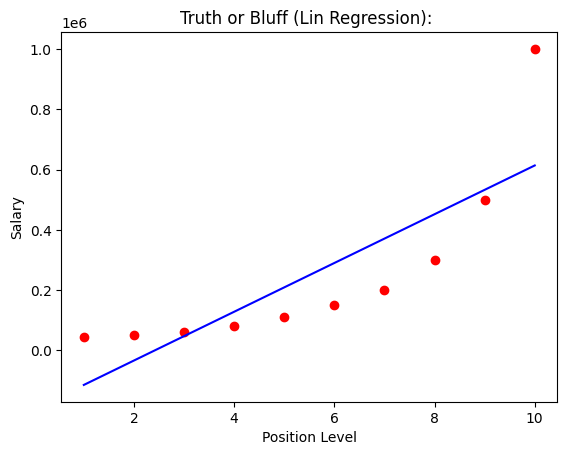

In [40]:
plt.scatter(X,y,color='red')
plt.plot(X,lin_regressor.predict(X),color='blue')
plt.title("Truth or Bluff (Lin Regression): ")
plt.xlabel("Position Level")
plt.ylabel("Salary")
plt.show()

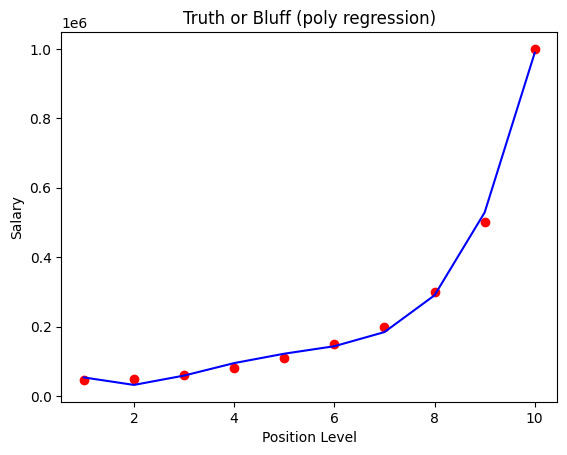

In [41]:
plt.scatter(X, y, color='red')
plt.plot(X, lin_regressor_2.predict(X_poly), color='blue')
plt.title("Truth or Bluff (poly regression)")
plt.xlabel("Position Level")
plt.ylabel("Salary")
plt.show()

In [44]:
lin_regressor.predict([[6.5]])

array([330378.79])

In [46]:
lin_regressor_2.predict(poly_reg.fit_transform([[6.5]]))

array([158862.45])

# Support Vector Regression